In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn import linear_model as lm
from functions import feature_selection, add_cross_terms, bootstrap_LOO


In [38]:
#Read in data file (see data_processing.ipynb for how this file is generated)
codes_and_CIs = pd.read_csv('combined_COPUS_CI_data.csv')

#Keep only Lec, CG, WG, OG, and SQ codes (see paper for discussion of feature selection)
#these will be input features for the model
data = codes_and_CIs[[  'CG', 'WG',  'SQ', 'OG' ]].to_numpy()
#This is a linear regression model, but we use nonlinear terms by adding polynomila features
data = add_cross_terms(data)

#The target variable is the effect size
######################################
target = codes_and_CIs['Effect Size'].to_numpy()

#target -= np.min(target) #shift to make all values positive
#target/= np.max(target) #scale to make all values between 0 and 1

ES_variance = codes_and_CIs['Effect Size Variance'].to_numpy()

In [64]:
#feature selection and aic functions are called in from functions.py
alpha = .0009

maxits = 1000000
#pick number of bootstrap samples and number of best fits to use for LOO predictions
bootstrap_n = 10
def LOO_bootstrap_Ridge(data, target, ES_variance, bootstrap_n, alpha, maxits):

    #create empty arrays to store weights and predictions for each bootstrap sample, each best fit, and each data point
    LOO_predictions = np.zeros(( bootstrap_n, data.shape[0]))
    LOO_weights = np.zeros(( bootstrap_n, data.shape[0], data.shape[1]))


    #perform leave-one-out cross-validation for each of the best fits
    for k in range(data.shape[0]): 
        cut_data = np.delete(data, k, axis=0)
        cut_truth = np.delete(target, k, axis=0)
        cut_weights = np.delete(1/np.sqrt(ES_variance), k, axis=0)

        for i in range(bootstrap_n):
            boot_inds = np.random.choice(cut_data.shape[0], int(cut_data.shape[0] * 0.95), replace=False)
            boot_data, boot_truth, boot_weights = cut_data[boot_inds], cut_truth[boot_inds], cut_weights[boot_inds]
            clf = lm.Ridge(alpha = alpha, max_iter = maxits)
            LOO_weights[i, k, :] = clf.fit(boot_data, boot_truth,sample_weight=boot_weights).coef_
            LOO_predictions[i, k] = clf.predict(data[k, :].reshape(1, -1))[0]
        #print(AICs[good_fits])
    return LOO_predictions, LOO_weights

def LOO_bootstrap_Lasso(data, target, ES_variance, bootstrap_n, alpha, maxits):

    #create empty arrays to store weights and predictions for each bootstrap sample, each best fit, and each data point
    LOO_predictions = np.zeros(( bootstrap_n, data.shape[0]))
    LOO_weights = np.zeros(( bootstrap_n, data.shape[0], data.shape[1]))


    #perform leave-one-out cross-validation for each of the best fits
    for k in range(data.shape[0]): 
        cut_data = np.delete(data, k, axis=0)
        cut_truth = np.delete(target, k, axis=0)
        cut_weights = np.delete(1/np.sqrt(ES_variance), k, axis=0)

        for i in range(bootstrap_n):
            boot_inds = np.random.choice(cut_data.shape[0], int(cut_data.shape[0] * 0.95), replace=False)
            boot_data, boot_truth, boot_weights = cut_data[boot_inds], cut_truth[boot_inds], cut_weights[boot_inds]
            clf = lm.Lasso(alpha = alpha, max_iter = maxits)
            LOO_weights[i, k, :] = clf.fit(boot_data, boot_truth,sample_weight=boot_weights).coef_
            LOO_predictions[i, k] = clf.predict(data[k, :].reshape(1, -1))[0]
        #print(AICs[good_fits])
    return LOO_predictions, LOO_weights

def LOO_bootstrap_ENet(data, target, ES_variance, bootstrap_n, alpha, l1_ratio,maxits, tol ):

    #create empty arrays to store weights and predictions for each bootstrap sample, each best fit, and each data point
    LOO_predictions = np.zeros(( bootstrap_n, data.shape[0]))
    LOO_weights = np.zeros(( bootstrap_n, data.shape[0], data.shape[1]))


    #perform leave-one-out cross-validation for each of the best fits
    for k in range(data.shape[0]): 
        cut_data = np.delete(data, k, axis=0)
        cut_truth = np.delete(target, k, axis=0)
        cut_weights = np.delete(1/np.sqrt(ES_variance), k, axis=0)

        for i in range(bootstrap_n):
            boot_inds = np.random.choice(cut_data.shape[0], int(cut_data.shape[0] * 0.95), replace=False)
            boot_data, boot_truth, boot_weights = cut_data[boot_inds], cut_truth[boot_inds], cut_weights[boot_inds]
            clf = lm.ElasticNet(max_iter = maxits, alpha = alpha, l1_ratio = l1_ratio, fit_intercept = False, tol = tol, selection = 'random')
            LOO_weights[i, k, :] = clf.fit(boot_data, boot_truth,sample_weight=boot_weights).coef_
            LOO_predictions[i, k] = clf.predict(data[k, :].reshape(1, -1))[0]
        #print(AICs[good_fits])
    return LOO_predictions, LOO_weights

def LOO_bootstrap_LassoAIC(data, target,  bootstrap_n, maxits,):

    #create empty arrays to store weights and predictions for each bootstrap sample, each best fit, and each data point
    LOO_predictions = np.zeros(( bootstrap_n, data.shape[0]))
    LOO_weights = np.zeros(( bootstrap_n, data.shape[0], data.shape[1]))


    #perform leave-one-out cross-validation for each of the best fits
    for k in range(data.shape[0]): 
        cut_data = np.delete(data, k, axis=0)
        cut_truth = np.delete(target, k, axis=0)
        cut_weights = np.delete(1/np.sqrt(ES_variance), k, axis=0)

        for i in range(bootstrap_n):
            boot_inds = np.random.choice(cut_data.shape[0], int(cut_data.shape[0] * 0.95), replace=False)
            boot_data, boot_truth, boot_weights = cut_data[boot_inds], cut_truth[boot_inds], cut_weights[boot_inds]
            clf = lm.LassoLarsIC(max_iter = maxits,  fit_intercept = False, criterion = 'bic')
            LOO_weights[i, k, :] = clf.fit(boot_data, boot_truth,).coef_
            LOO_predictions[i, k] = clf.predict(data[k, :].reshape(1, -1))[0]
        #print(AICs[good_fits])
    return LOO_predictions, LOO_weights



R^2: 0.5394095032187968
MAE: 0.31574663374377415


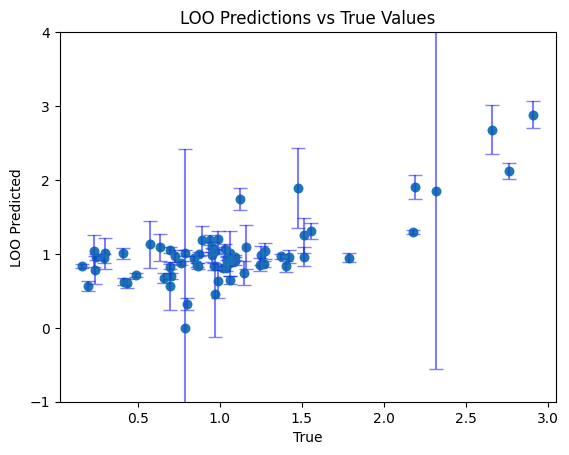

MAE for low error points: 0.31
R^2 for low error points: 0.5


: 

In [ ]:

LOO_predictions, LOO_weights = LOO_bootstrap_LassoAIC(data, target, 50, int(1e5),)
LOO_means = np.mean(LOO_predictions, axis=0)
LOO_stds = np.std(LOO_predictions, axis=0)
plt.scatter( target, LOO_means,)

print(f'R^2: {np.corrcoef(LOO_means, target)[0,1]**2}')
print(f'MAE: {np.mean(np.abs(LOO_means - target))}')

plt.errorbar(target,LOO_means, yerr=LOO_stds, fmt='o', ecolor='blue', capsize=5, alpha = .5)
plt.ylabel('LOO Predicted')
plt.xlabel('True')
plt.ylim(-1, 4)
plt.title('LOO Predictions vs True Values')
plt.show()

low_err_idx = np.where(LOO_stds < .3)
print(f'MAE for low error points: {np.round(np.mean(np.abs(LOO_means[low_err_idx] - target[low_err_idx])), 2)}')
print(f'R^2 for low error points: {np.round(np.corrcoef(LOO_means[low_err_idx], target[low_err_idx])[0,1]**2, 2)}')

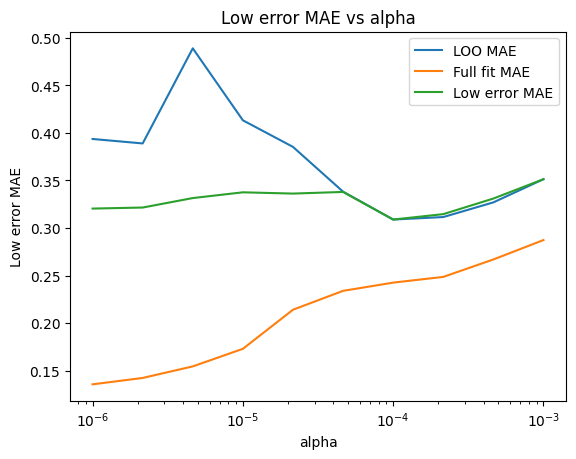

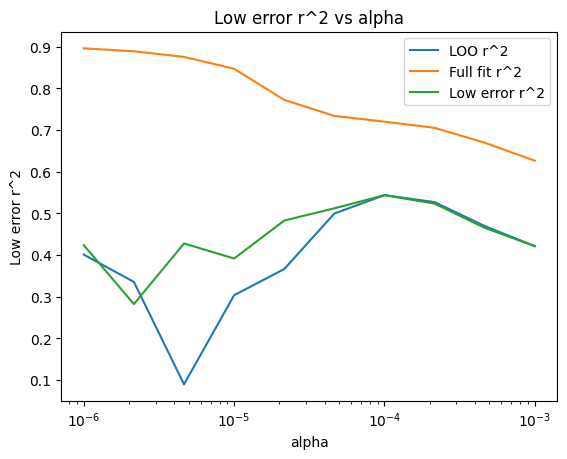

In [43]:
df = pd.DataFrame(columns = ['alpha', 'LOO MAE', 'LOO r^2', 'Full fit MAE', 'Full fit r^2', 'Low error MAE', 'Low error r^2', ])
alphas = np.logspace(-6, -3, 10)
maxits = 1000000
l1 = 1
bootstrap_n = 10
for a in alphas:
    LOO_predictions, LOO_weights = LOO_bootstrap_ENet(data, target, ES_variance, bootstrap_n, a, l1,  maxits, tol = 1e-2)
    LOO_means = np.mean(LOO_predictions, axis=0)
    LOO_STDs = np.std(LOO_predictions, axis=0)
    LOO_MAE = np.mean(np.abs(LOO_means - target))
    LOO_r2 = np.corrcoef(LOO_means, target)[0, 1]**2
    clf = lm.ElasticNet(alpha = a, l1_ratio = l1,max_iter = maxits, fit_intercept = False, tol = 1e-2, selection = 'random')
    clf.fit(data, target) 
    full_fit_MAE = np.mean(np.abs(clf.predict(data) - target))
    full_fit_r2 = clf.score(data, target)
    low_error_inds = np.where(LOO_STDs < .3)[0]
    low_error_MAE = np.mean(np.abs(LOO_means[low_error_inds] - target[low_error_inds]))
    low_error_r2 = np.corrcoef(LOO_means[low_error_inds], target[low_error_inds])[0, 1]**2
    df.loc[len(df)] = [a, LOO_MAE, LOO_r2, full_fit_MAE, full_fit_r2, low_error_MAE, low_error_r2]

for label in ['LOO MAE','Full fit MAE',  'Low error MAE', ]:
    plt.plot(df['alpha'], df[label], label=label)
    plt.xscale('log')
    plt.xlabel('alpha')
    plt.ylabel(label)
    plt.title(label + ' vs alpha')
    plt.legend()
plt.show()
for label in ['LOO r^2','Full fit r^2',  'Low error r^2', ]:
    plt.plot(df['alpha'], df[label], label=label)
    plt.xscale('log')
    plt.xlabel('alpha')
    plt.ylabel(label)
    plt.title(label + ' vs alpha')
    plt.legend()
plt.show()

### Ridge without OG

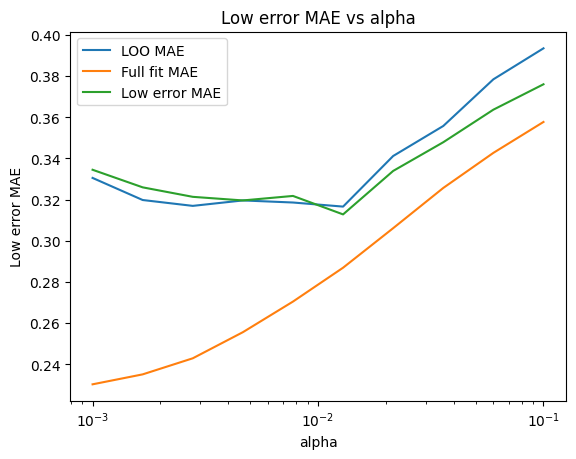

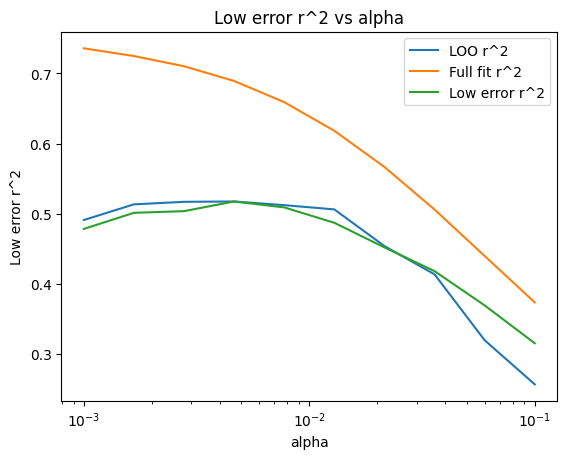

In [212]:
df = pd.DataFrame(columns = ['alpha', 'LOO MAE', 'LOO r^2', 'Full fit MAE', 'Full fit r^2', 'Low error MAE', 'Low error r^2', ])
alphas = np.logspace(-3, -1, 10)
maxits = 1000000
for a in alphas:
    LOO_predictions, LOO_weights = LOO_bootstrap_Ridge(data, target, ES_variance, bootstrap_n, a, maxits)
    LOO_means = np.mean(LOO_predictions, axis=0)
    LOO_STDs = np.std(LOO_predictions, axis=0)
    LOO_MAE = np.mean(np.abs(LOO_means - target))
    LOO_r2 = np.corrcoef(LOO_means, target)[0, 1]**2
    clf = lm.Ridge(alpha = a, max_iter = maxits)
    clf.fit(data, target)
    full_fit_MAE = np.mean(np.abs(clf.predict(data) - target))
    full_fit_r2 = clf.score(data, target)
    low_error_inds = np.where(LOO_STDs < .3)[0]
    low_error_MAE = np.mean(np.abs(LOO_means[low_error_inds] - target[low_error_inds]))
    low_error_r2 = np.corrcoef(LOO_means[low_error_inds], target[low_error_inds])[0, 1]**2
    df.loc[len(df)] = [a, LOO_MAE, LOO_r2, full_fit_MAE, full_fit_r2, low_error_MAE, low_error_r2]

for label in ['LOO MAE','Full fit MAE',  'Low error MAE', ]:
    plt.plot(df['alpha'], df[label], label=label)
    plt.xscale('log')
    plt.xlabel('alpha')
    plt.ylabel(label)
    plt.title(label + ' vs alpha')
    plt.legend()
plt.show()
for label in ['LOO r^2','Full fit r^2',  'Low error r^2', ]:
    plt.plot(df['alpha'], df[label], label=label)
    plt.xscale('log')
    plt.xlabel('alpha')
    plt.ylabel(label)
    plt.title(label + ' vs alpha')
    plt.legend()
plt.show()

#### LASSO without OG

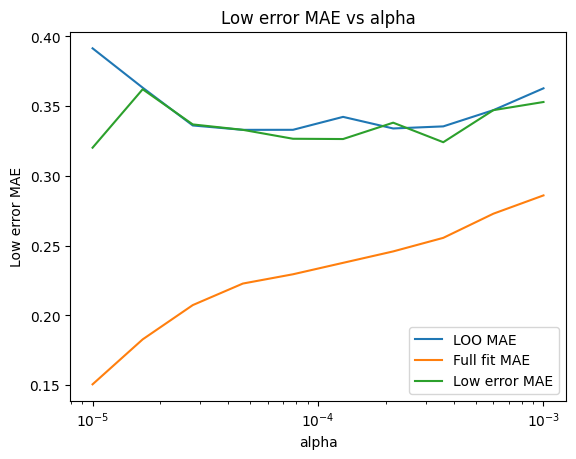

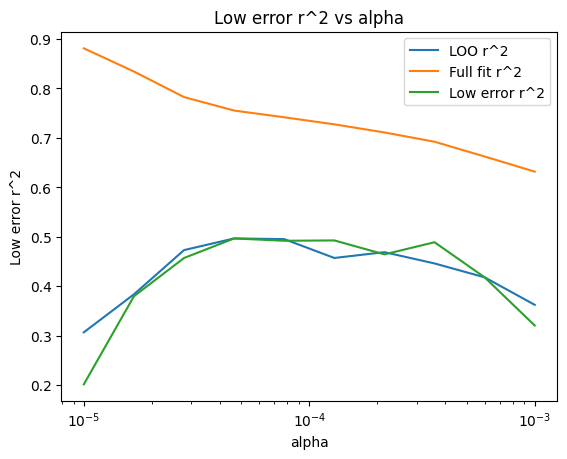

In [211]:
df = pd.DataFrame(columns = ['alpha', 'LOO MAE', 'LOO r^2', 'Full fit MAE', 'Full fit r^2', 'Low error MAE', 'Low error r^2', ])
alphas = np.logspace(-5, -3, 10)
maxits = 1000000
for a in alphas:
    LOO_predictions, LOO_weights = LOO_bootstrap_Lasso(data, target, ES_variance, bootstrap_n, a, maxits)
    LOO_means = np.mean(LOO_predictions, axis=0)
    LOO_STDs = np.std(LOO_predictions, axis=0)
    LOO_MAE = np.mean(np.abs(LOO_means - target))
    LOO_r2 = np.corrcoef(LOO_means, target)[0, 1]**2
    clf = lm.Lasso(alpha = a, max_iter = maxits)
    clf.fit(data, target)
    full_fit_MAE = np.mean(np.abs(clf.predict(data) - target))
    full_fit_r2 = clf.score(data, target)
    low_error_inds = np.where(LOO_STDs < .3)[0]
    low_error_MAE = np.mean(np.abs(LOO_means[low_error_inds] - target[low_error_inds]))
    low_error_r2 = np.corrcoef(LOO_means[low_error_inds], target[low_error_inds])[0, 1]**2
    df.loc[len(df)] = [a, LOO_MAE, LOO_r2, full_fit_MAE, full_fit_r2, low_error_MAE, low_error_r2]

for label in ['LOO MAE','Full fit MAE',  'Low error MAE', ]:
    plt.plot(df['alpha'], df[label], label=label)
    plt.xscale('log')
    plt.xlabel('alpha')
    plt.ylabel(label)
    plt.title(label + ' vs alpha')
    plt.legend()
plt.show()
for label in ['LOO r^2','Full fit r^2',  'Low error r^2', ]:
    plt.plot(df['alpha'], df[label], label=label)
    plt.xscale('log')
    plt.xlabel('alpha')
    plt.ylabel(label)
    plt.title(label + ' vs alpha')
    plt.legend()
plt.show()

### Lasso with OG

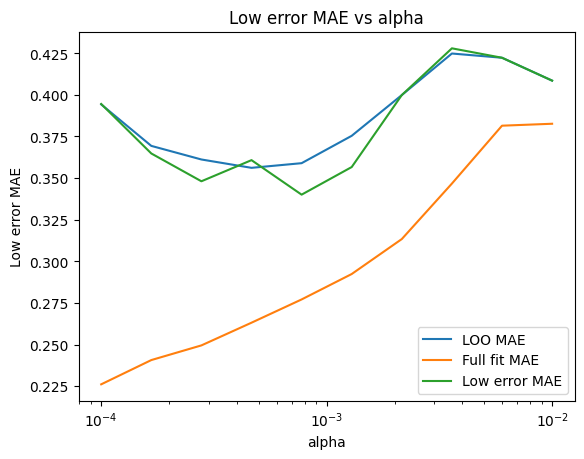

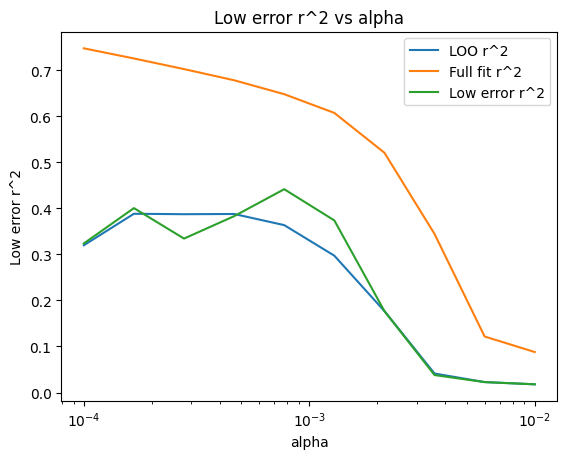

In [206]:
df = pd.DataFrame(columns = ['alpha', 'LOO MAE', 'LOO r^2', 'Full fit MAE', 'Full fit r^2', 'Low error MAE', 'Low error r^2', ])
alphas = np.logspace(-4, -2, 10)
maxits = 1000000
for a in alphas:
    LOO_predictions, LOO_weights = LOO_bootstrap_Lasso(data, target, ES_variance, bootstrap_n, a, maxits)
    LOO_means = np.mean(LOO_predictions, axis=0)
    LOO_STDs = np.std(LOO_predictions, axis=0)
    LOO_MAE = np.mean(np.abs(LOO_means - target))
    LOO_r2 = np.corrcoef(LOO_means, target)[0, 1]**2
    clf = lm.Lasso(alpha = a, max_iter = maxits)
    clf.fit(data, target)
    full_fit_MAE = np.mean(np.abs(clf.predict(data) - target))
    full_fit_r2 = clf.score(data, target)
    low_error_inds = np.where(LOO_STDs < .3)[0]
    low_error_MAE = np.mean(np.abs(LOO_means[low_error_inds] - target[low_error_inds]))
    low_error_r2 = np.corrcoef(LOO_means[low_error_inds], target[low_error_inds])[0, 1]**2
    df.loc[len(df)] = [a, LOO_MAE, LOO_r2, full_fit_MAE, full_fit_r2, low_error_MAE, low_error_r2]

for label in ['LOO MAE','Full fit MAE',  'Low error MAE', ]:
    plt.plot(df['alpha'], df[label], label=label)
    plt.xscale('log')
    plt.xlabel('alpha')
    plt.ylabel(label)
    plt.title(label + ' vs alpha')
    plt.legend()
plt.show()
for label in ['LOO r^2','Full fit r^2',  'Low error r^2', ]:
    plt.plot(df['alpha'], df[label], label=label)
    plt.xscale('log')
    plt.xlabel('alpha')
    plt.ylabel(label)
    plt.title(label + ' vs alpha')
    plt.legend()
plt.show()

### Ridge with OG

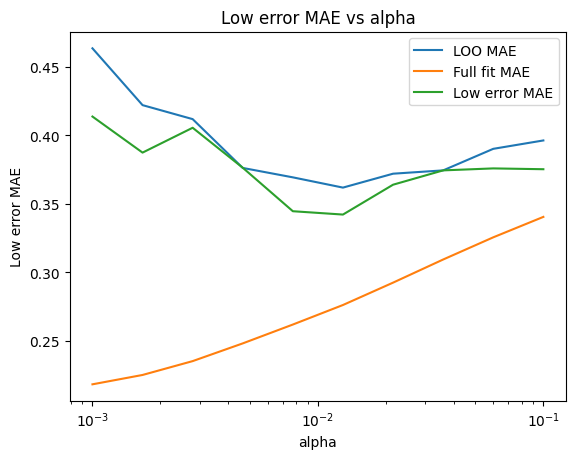

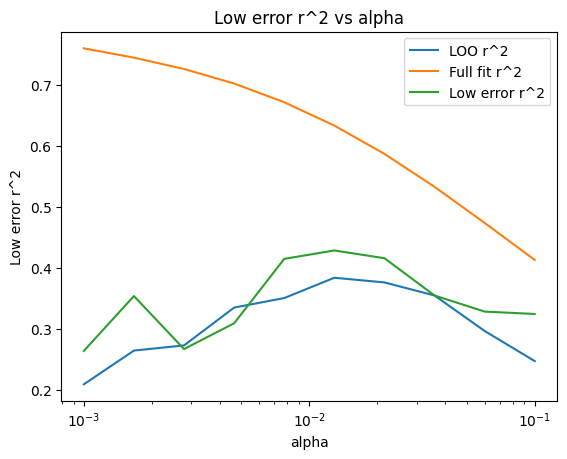

In [207]:
df = pd.DataFrame(columns = ['alpha', 'LOO MAE', 'LOO r^2', 'Full fit MAE', 'Full fit r^2', 'Low error MAE', 'Low error r^2', ])
alphas = np.logspace(-3, -1, 10)
maxits = 1000000
for a in alphas:
    LOO_predictions, LOO_weights = LOO_bootstrap_Ridge(data, target, ES_variance, bootstrap_n, a, maxits)
    LOO_means = np.mean(LOO_predictions, axis=0)
    LOO_STDs = np.std(LOO_predictions, axis=0)
    LOO_MAE = np.mean(np.abs(LOO_means - target))
    LOO_r2 = np.corrcoef(LOO_means, target)[0, 1]**2
    clf = lm.Ridge(alpha = a, max_iter = maxits)
    clf.fit(data, target)
    full_fit_MAE = np.mean(np.abs(clf.predict(data) - target))
    full_fit_r2 = clf.score(data, target)
    low_error_inds = np.where(LOO_STDs < .3)[0]
    low_error_MAE = np.mean(np.abs(LOO_means[low_error_inds] - target[low_error_inds]))
    low_error_r2 = np.corrcoef(LOO_means[low_error_inds], target[low_error_inds])[0, 1]**2
    df.loc[len(df)] = [a, LOO_MAE, LOO_r2, full_fit_MAE, full_fit_r2, low_error_MAE, low_error_r2]

for label in ['LOO MAE','Full fit MAE',  'Low error MAE', ]:
    plt.plot(df['alpha'], df[label], label=label)
    plt.xscale('log')
    plt.xlabel('alpha')
    plt.ylabel(label)
    plt.title(label + ' vs alpha')
    plt.legend()
plt.show()
for label in ['LOO r^2','Full fit r^2',  'Low error r^2', ]:
    plt.plot(df['alpha'], df[label], label=label)
    plt.xscale('log')
    plt.xlabel('alpha')
    plt.ylabel(label)
    plt.title(label + ' vs alpha')
    plt.legend()
plt.show()

 LOO MAE: 0.31
 LOO R^2: 0.51

 Full fit MAE: 0.21
 Full fit R^2: 0.75

MAE removing high error: 0.31
R^2 removing high error: 0.51


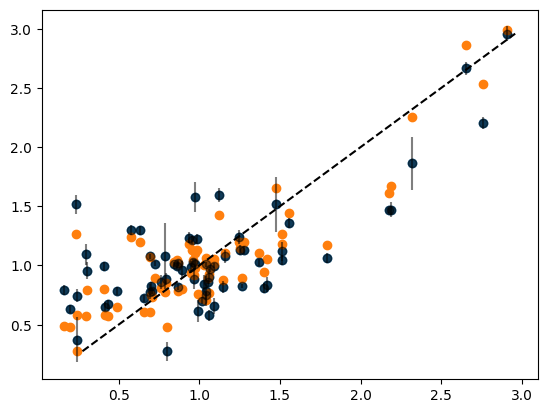

In [219]:
LOO_predictions, LOO_weights = LOO_bootstrap_Ridge(data, target, ES_variance, 100, 1e-2, maxits)
LOO_means = np.mean(LOO_predictions, axis=0)
LOO_stds = np.std(LOO_predictions, axis=0)

plot_target = 1*target
plt.scatter(plot_target, LOO_means,)
plt.plot([min(LOO_means), max(LOO_means)], [min(LOO_means), max(LOO_means)], color='k', ls='--')
plt.errorbar( plot_target, LOO_means, yerr=LOO_stds, fmt='o', color='k', alpha=0.5)
print(f' LOO MAE: {np.round(np.mean(np.abs(LOO_means - plot_target)), 2)}')
print(f' LOO R^2: {np.round(np.corrcoef(LOO_means, plot_target)[0, 1]**2, 2)}')

# show full fit
all_preds = np.zeros((bootstrap_n, data.shape[0]))
for i in range(bootstrap_n):
    boot_inds = np.random.choice(data.shape[0], int(data.shape[0] * 0.95), replace=False)
    boot_data, boot_truth, boot_weights = data[boot_inds], target[boot_inds], 1/np.sqrt(ES_variance)[boot_inds]
    clf = lm.Ridge(alpha = alpha, max_iter = maxits)
    all_preds[i] = clf.fit(boot_data, boot_truth, sample_weight=boot_weights).predict(data)
plt.scatter( target, np.mean(all_preds, axis=0),)
print('')
print(f' Full fit MAE: {np.round(np.mean(np.abs(np.mean(all_preds, axis=0) - plot_target)), 2)}')
print(f' Full fit R^2: {np.round(np.corrcoef(np.mean(all_preds, axis=0), plot_target)[0, 1]**2, 2)}')


print('')
low_error_inds = np.where(LOO_stds < .3)[0]
print(f'MAE removing high error: {np.round(np.mean(np.abs(LOO_means[low_error_inds] - plot_target[low_error_inds])), 2)}')
print(f'R^2 removing high error: {np.round(np.corrcoef(LOO_means[low_error_inds], plot_target[low_error_inds])[0, 1]**2, 2)}')
